In [68]:
from Bio import SeqIO
import pandas as pd

#loading the columns of the sars hum dataframe
df_sars_hum = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t", usecols=["pdb", "light_subclass", "antigen_species"])
df_sars_hum['pdb'] = df_sars_hum['pdb'].str.lower().str.strip()
print(df_sars_hum.head())

    pdb            antigen_species light_subclass
0  8wu1  bos taurus | homo sapiens          IGKV1
1  3lqa       hiv-1 | homo sapiens          IGLV1
2  4kxz               homo sapiens          IGKV3
3  6vmk               homo sapiens          IGKV1
4  6vmk               homo sapiens          IGKV1


In [69]:
import numpy as np
import pandas as pd
#loading distance matrix 
dist_matrix = pd.read_csv("../../blasting/mmseqs/distance_matrix.csv", index_col=0)

#consistent formating
dist_matrix.index = dist_matrix.index.str.strip()
dist_matrix.columns = dist_matrix.columns.str.strip()
pdb_id = df_sars_hum['pdb'].unique()

#creating a dataframe with merged distance matrix and gene families with the pdb-IDs 
def extract_pdb(full_id):
    return full_id.split('_')[0].lower()  #lowercase to match pdb IDs like '8wu1'

#rows and columns are applied to the matrix
dist_matrix.index = dist_matrix.index.map(extract_pdb)
dist_matrix.columns = dist_matrix.columns.map(extract_pdb)

df_sars_hum = df_sars_hum[df_sars_hum['pdb'].isin(dist_matrix.index)]
print(dist_matrix.shape)


matrix_pdb = sorted(set(dist_matrix.index).intersection(pdb_id))
dist_matrix = dist_matrix.loc[matrix_pdb, matrix_pdb]
dist_matrix.to_csv("distance_matrix_light_subclass.csv")
print(dist_matrix.head)


(1013, 1013)
<bound method NDFrame.head of        1adq   1h0d   1i9r   1iqd   1jps   1uj3   1w72   2b4c   2fjh   2j6e  \
1adq  0.000  1.000  1.000  1.000  1.000  1.000  0.044  1.000  1.000  0.226   
1h0d  1.000  0.000  0.349  1.000  1.000  1.000  1.000  0.413  0.395  1.000   
1i9r  1.000  0.349  0.000  1.000  0.179  0.184  1.000  1.000  0.156  1.000   
1iqd  1.000  1.000  1.000  0.000  0.185  1.000  1.000  0.072  0.162  1.000   
1jps  1.000  1.000  0.179  0.185  0.000  0.043  1.000  0.196  0.080  1.000   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9j66  1.000  0.418  0.175  0.190  0.099  0.103  1.000  0.196  0.066  1.000   
9l6c  1.000  1.000  1.000  0.102  1.000  1.000  1.000  0.111  1.000  1.000   
9l6c  1.000  1.000  1.000  1.000  0.176  1.000  1.000  1.000  0.139  1.000   
9l6c  1.000  1.000  1.000  0.075  1.000  1.000  1.000  0.084  1.000  1.000   
9mi6  0.215  1.000  1.000  1.000  1.000  1.000  0.239  1.000  1.000  0.209   

      ...   9dh2   9

/home/barth/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/barth/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


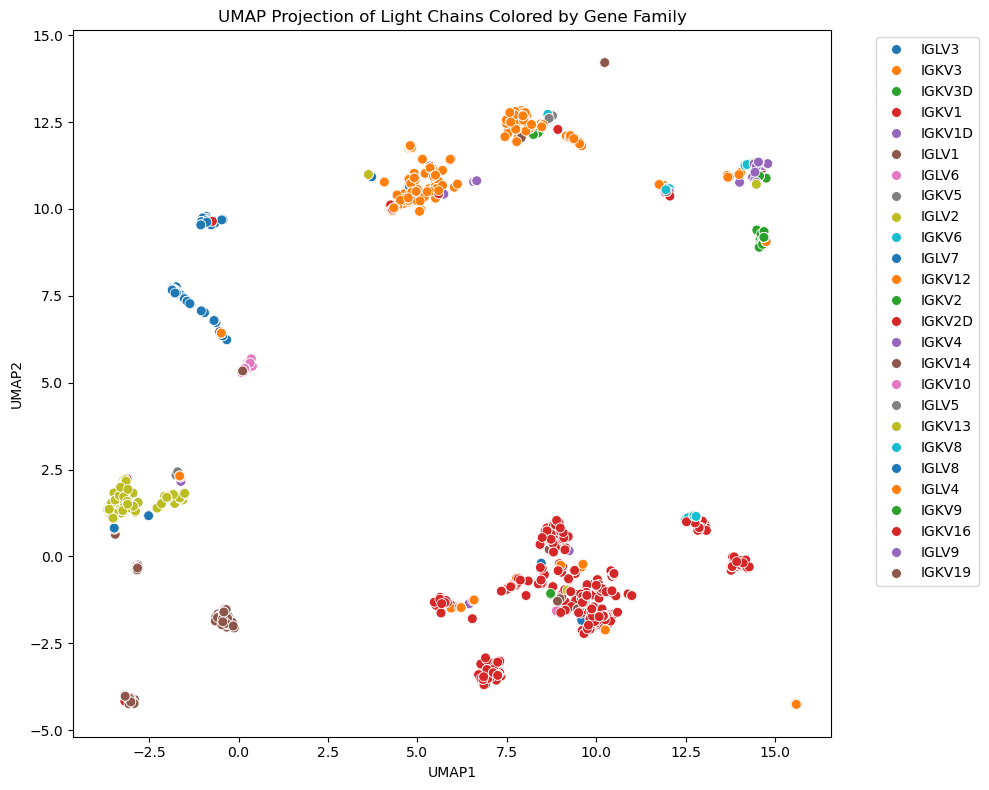

In [57]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

#umap projection
reducer = umap.UMAP(metric='precomputed', random_state=42)
embedding = reducer.fit_transform(dist_matrix)

df_umap = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
df_umap["pdb"] = dist_matrix.index
df_umap = df_umap.merge(df_sars_hum, on="pdb", how="left")

#plotting the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="light_subclass", palette="tab10", s=50)
plt.title("UMAP Projection of Light Chains Colored by Gene Family")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
import os
import subprocess
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import AlignInfo
from Bio import AlignIO
from collections import defaultdict

fasta_file = "../../blasting/mmseqs/lchain_sequences_deduplicated.fasta"
seq_dict = {
    rec.id.lower().split('_')[0].strip(): rec
    for rec in SeqIO.parse(fasta_file, "fasta")
}


dist_list = [x.lower().strip() for x in dist_matrix.index.tolist()]
df_sars_hum['pdb'] = df_sars_hum['pdb'].str.lower().str.strip()
df_sars_hum = df_sars_hum[df_sars_hum['pdb'].isin(dist_list)]


print(df_sars_hum.head())
print(dist_list)

    pdb            antigen_species light_subclass
0  8wu1  bos taurus | homo sapiens          IGKV1
1  3lqa       hiv-1 | homo sapiens          IGLV1
2  4kxz               homo sapiens          IGKV3
3  6vmk               homo sapiens          IGKV1
4  6vmk               homo sapiens          IGKV1
['1adq', '1h0d', '1i9r', '1iqd', '1jps', '1uj3', '1w72', '2b4c', '2fjh', '2j6e', '2qql', '2qqn', '2qr0', '2uzi', '2vh5', '2vxs', '2wub', '2xqb', '2xtj', '2xwt', '3bn9', '3d85', '3dvg', '3dvn', '3eob', '3g04', '3g6d', '3g6j', '3gjf', '3grw', '3hae', '3hi6', '3hmx', '3jwo', '3kr3', '3l5x', '3lqa', '3mxw', '3n85', '3nfp', '3nh7', '3nps', '3p0y', '3q1s', '3r1g', '3skj', '3so3', '3sob', '3sqo', '3t2n', '3thm', '3tje', '3u30', '3ulu', '3ulu', '3ulu', '3wd5', '3wlw', '3wsq', '3x3f', '4cni', '4d9r', '4dke', '4dkf', '4dn4', '4dtg', '4edw', '4ers', '4g3y', '4g6j', '4g6m', '4h8w', '4hcr', '4hj0', '4hwb', '4i2x', '4i77', '4j4p', '4k8r', '4k8r', '4kxz', '4lmq', '4mxw', '4n90', '4od2', '4ogx', '4oqt', '4p

In [59]:
grouped_sequences = defaultdict(list)

for _, row in df_sars_hum.iterrows():
    pdb_id = row['pdb']
    subclass = row['light_subclass']
    if pdb_id in seq_dict:
        grouped_sequences[subclass].append(seq_dict[pdb_id])


written_files = []

for subclass, recs in grouped_sequences.items():
    if len(recs) > 1:
        for rec in recs:
            rec.id = rec.id.split()[0]
            rec.id = rec.id.replace(">", "").strip()
            rec.name = rec.id
            rec.description = ""

        input_path = f"clustal_alignments/{subclass}_in.fasta"
        SeqIO.write(recs, input_path, "fasta")
        written_files.append(input_path)

print("Files written:")
for path in written_files:
    print(f"  - {path}")

print("PDBs from df_sars_hum:", df_sars_hum['pdb'].unique()[:5])
print("Keys from seq_dict:", list(seq_dict.keys())[:5])

Files written:
  - clustal_alignments/IGKV1_in.fasta
  - clustal_alignments/IGLV1_in.fasta
  - clustal_alignments/IGKV3_in.fasta
  - clustal_alignments/IGKV6_in.fasta
  - clustal_alignments/IGKV14_in.fasta
  - clustal_alignments/IGKV4_in.fasta
  - clustal_alignments/IGLV7_in.fasta
  - clustal_alignments/IGLV3_in.fasta
  - clustal_alignments/IGKV3D_in.fasta
  - clustal_alignments/IGLV8_in.fasta
  - clustal_alignments/IGKV12_in.fasta
  - clustal_alignments/IGKV2_in.fasta
  - clustal_alignments/IGKV16_in.fasta
  - clustal_alignments/IGKV1D_in.fasta
  - clustal_alignments/IGLV2_in.fasta
  - clustal_alignments/IGKV5_in.fasta
  - clustal_alignments/IGLV6_in.fasta
  - clustal_alignments/IGKV10_in.fasta
  - clustal_alignments/IGKV19_in.fasta
  - clustal_alignments/IGKV8_in.fasta
  - clustal_alignments/IGKV13_in.fasta
  - clustal_alignments/IGKV9_in.fasta
  - clustal_alignments/IGKV2D_in.fasta
  - clustal_alignments/IGLV5_in.fasta
  - clustal_alignments/IGLV4_in.fasta
  - clustal_alignments/IGL

In [60]:
for subclass in grouped_sequences:
    in_path = f"clustal_alignments/{subclass}_in.fasta"
    out_path = f"clustal_alignments/{subclass}_aligned.fasta"
    
    if os.path.exists(in_path):
        subprocess.run([
            "clustalo", "-i", in_path,
            "-o", out_path,
            "--force", "--outfmt", "fasta"
        ], check=True)

In [61]:
consensus_dict = {}

for subclass in grouped_sequences:
    aligned_path = f"clustal_alignments/{subclass}_aligned.fasta"
    if os.path.exists(aligned_path):
        alignment = AlignIO.read(aligned_path, "fasta")
        summary = AlignInfo.SummaryInfo(alignment)
        consensus = summary.dumb_consensus(threshold=0.7, ambiguous='_')
        consensus_dict[subclass] = str(consensus)

for subclass, consensus in consensus_dict.items():
    print(f">{subclass}\n{consensus}")


/home/barth/miniforge3/lib/python3.12/site-packages/Bio/Align/AlignInfo.py:62: BiopythonDeprecationWarning: The `dumb_consensus` method is deprecated and will be removed in a future release of Biopython. As an alternative, you can convert the multiple sequence alignment object to a new-style Alignment object by via its `.alignment` property, and then create a Motif object. You can then use the `.consensus` or `.degenerate_consensus` property of the Motif object to get a consensus sequence. For more control over how the consensus sequence is calculated, you can call the `calculate_consensus` method on the `.counts` property of the Motif object. This is an example for a multiple sequence alignment `msa` of DNA nucleotides:
>>> from Bio.Seq import Seq
>>> from Bio.SeqRecord import SeqRecord
>>> from Bio.Align import MultipleSeqAlignment
>>> from Bio.Align.AlignInfo import SummaryInfo
>>> msa = MultipleSeqAlignment([SeqRecord(Seq('ACGT')),
...                             SeqRecord(Seq('ATG

>IGKV1
MD_K___IHNHHK___________________DIQMTQSPSSLSASVGDRVTITCRASQ___Y_______L_WYQQKPGKAPKLLIY_AST_L_SGVPSRFSSRATLTGSGSGTDFTLTISSLQPEDFATYYCQQ__________TFG_GTKVEIKR_T_VAAPSVFIFS__PPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS__________QLIMVTNKAIASQ
>IGLV1
MGILPSPGM_______L_L_____G__S_QSVLTQPPS_S__PGQRVTISC_GS_SNLY_NIG____V_WYQQQLPG_APKLLIY____RPSGVPDRFSGSKSGSSTSASLAI_GLQ_EDEADYYC___D_SL_____VFGGGTK_TVL_TKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGSVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSSSTVEKTVAPTECSAAENLYFQGS
>IGKV3
PNITNLCP____________L_________NCVAEIV_TQSP_TLSLSPGERATLSCRASQSV___DLCFTNVYA_______LAWYQQKPGQAPRLLIY_AS_RATGIP_RFSGSGSGTDFTLTIS_LEPEDFAVYYCQQ____PS____TFG_GTKVQ_EIKRT___PTVSIFPPSSEQLTSGGASVVCFTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC____Q______TNGVGY_______LS_A_________C__T__GL____________H
>IGKV6
DIV_TQ___F_S_S____V_ITC_ASQ____YGIS___WYQQKP_QS

In [52]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

records = [SeqRecord(Seq(seq), id=subclass, description="") for subclass, seq in consensus_dict.items()]
SeqIO.write(records, "consensus_by_light_subclass.fasta", "fasta")


26

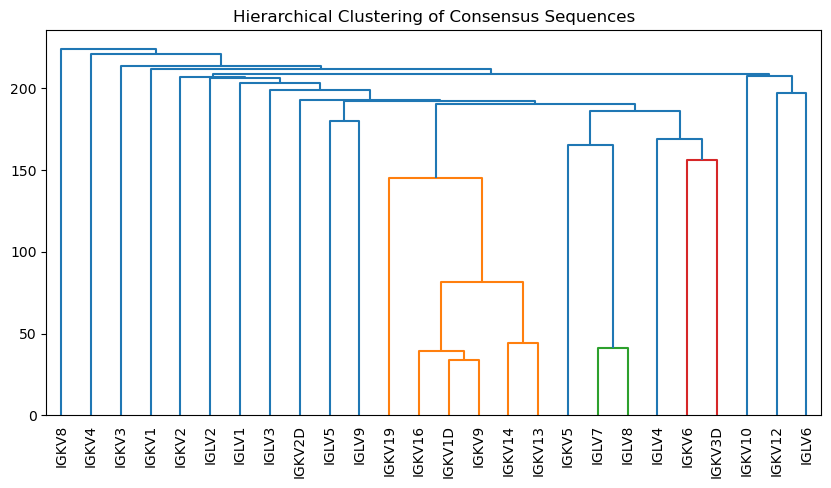

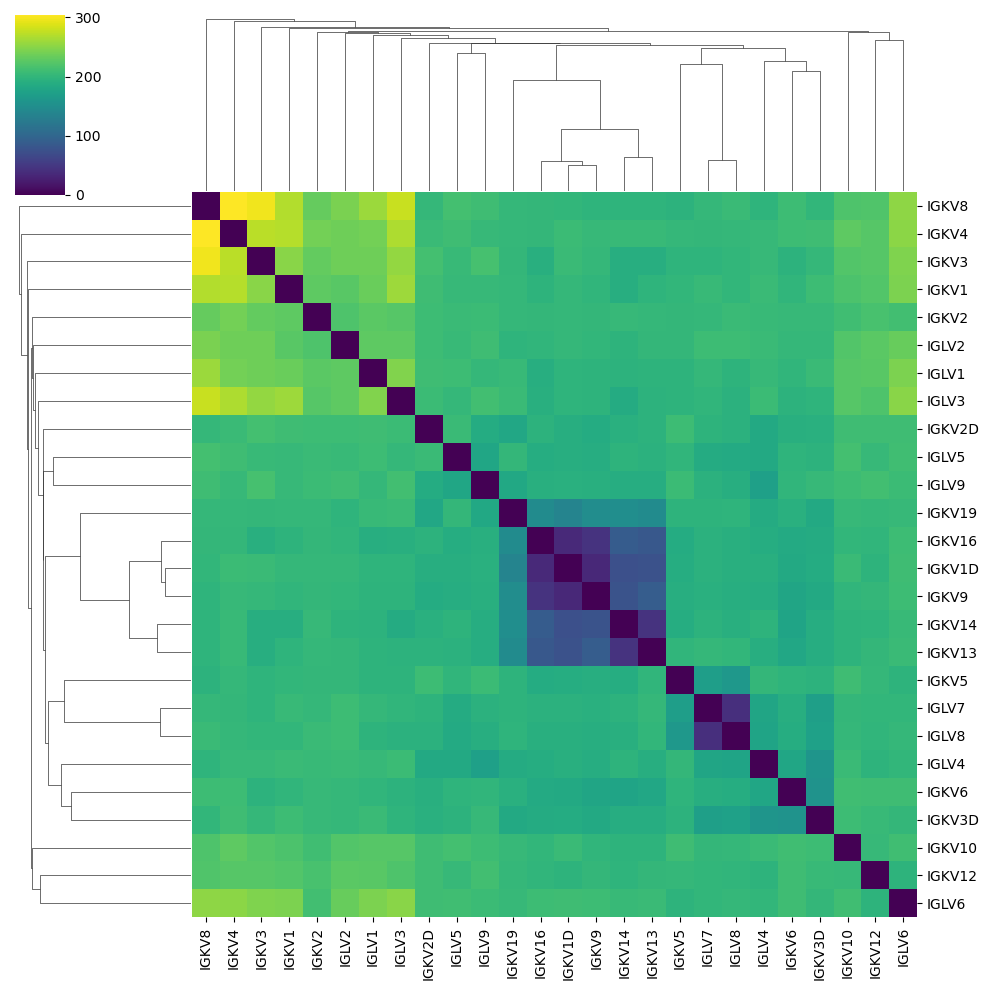

In [ ]:
#visualisation of the consensus sequences
import numpy as np
from scipy.spatial.distance import pdist, squareform

def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))

sequences = list(consensus_dict.values())
labels = list(consensus_dict.keys())

dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram


linkage_matrix = linkage(squareform(dist_matrix), method='average')


plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
plt.title("Hierarchical Clustering of Consensus Sequences")
plt.show()


sns.clustermap(dist_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix,
               row_cluster=True, col_cluster=True,
               xticklabels=labels, yticklabels=labels,
               cmap="viridis")
plt.show()



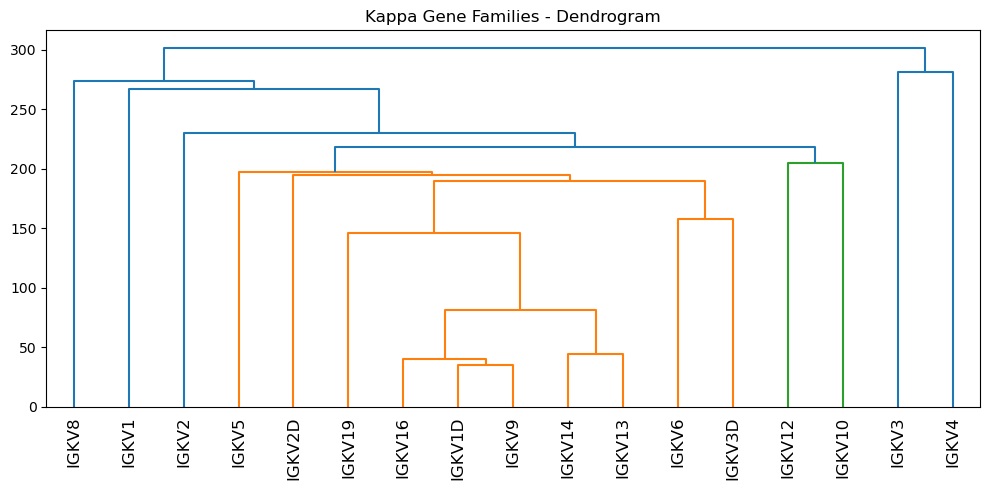

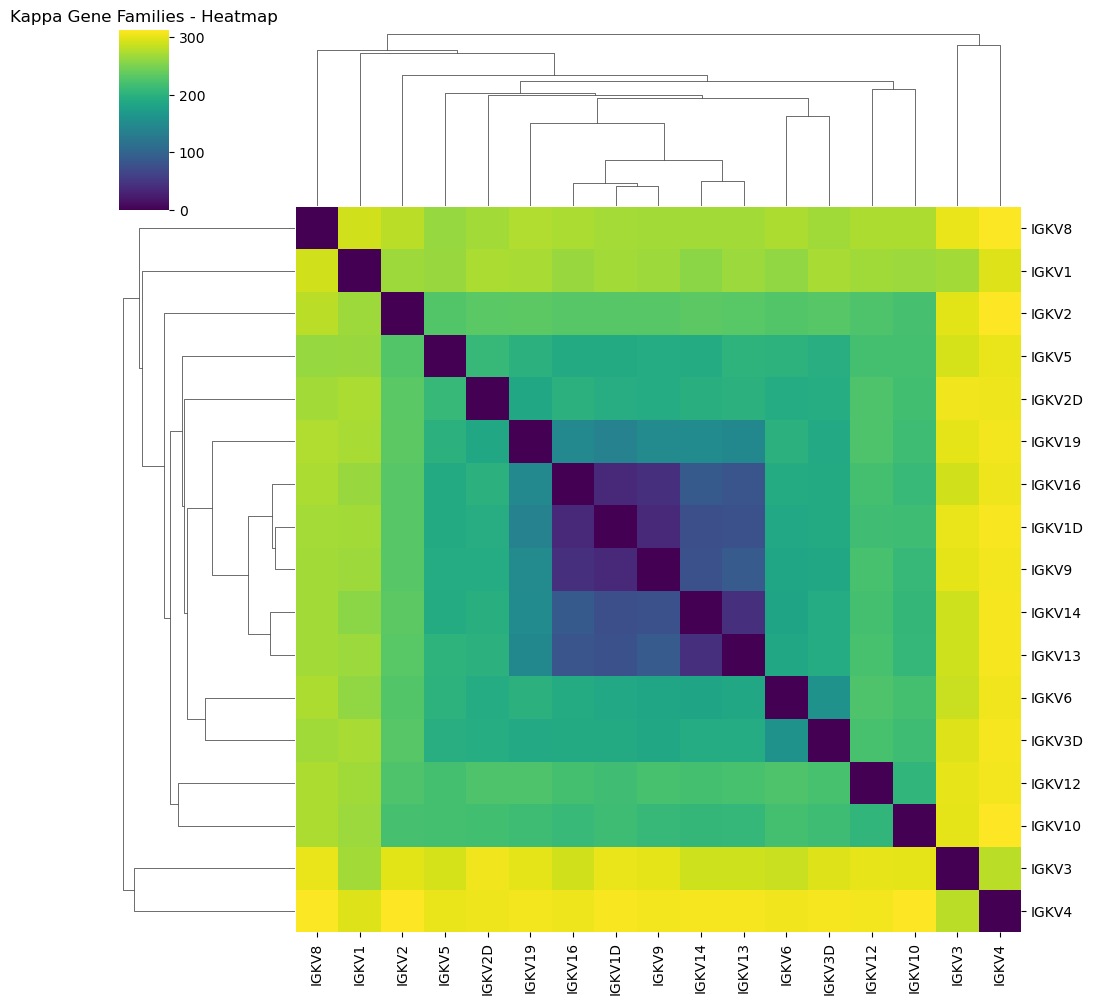

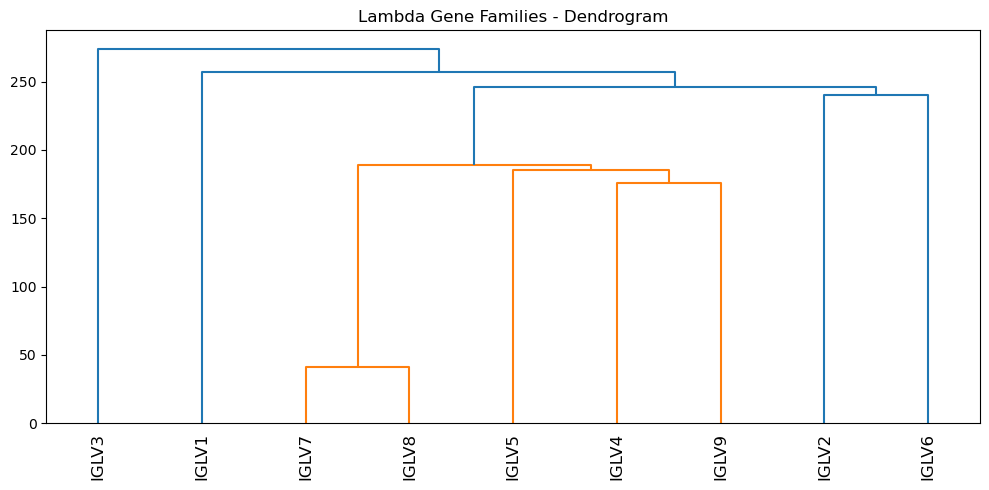

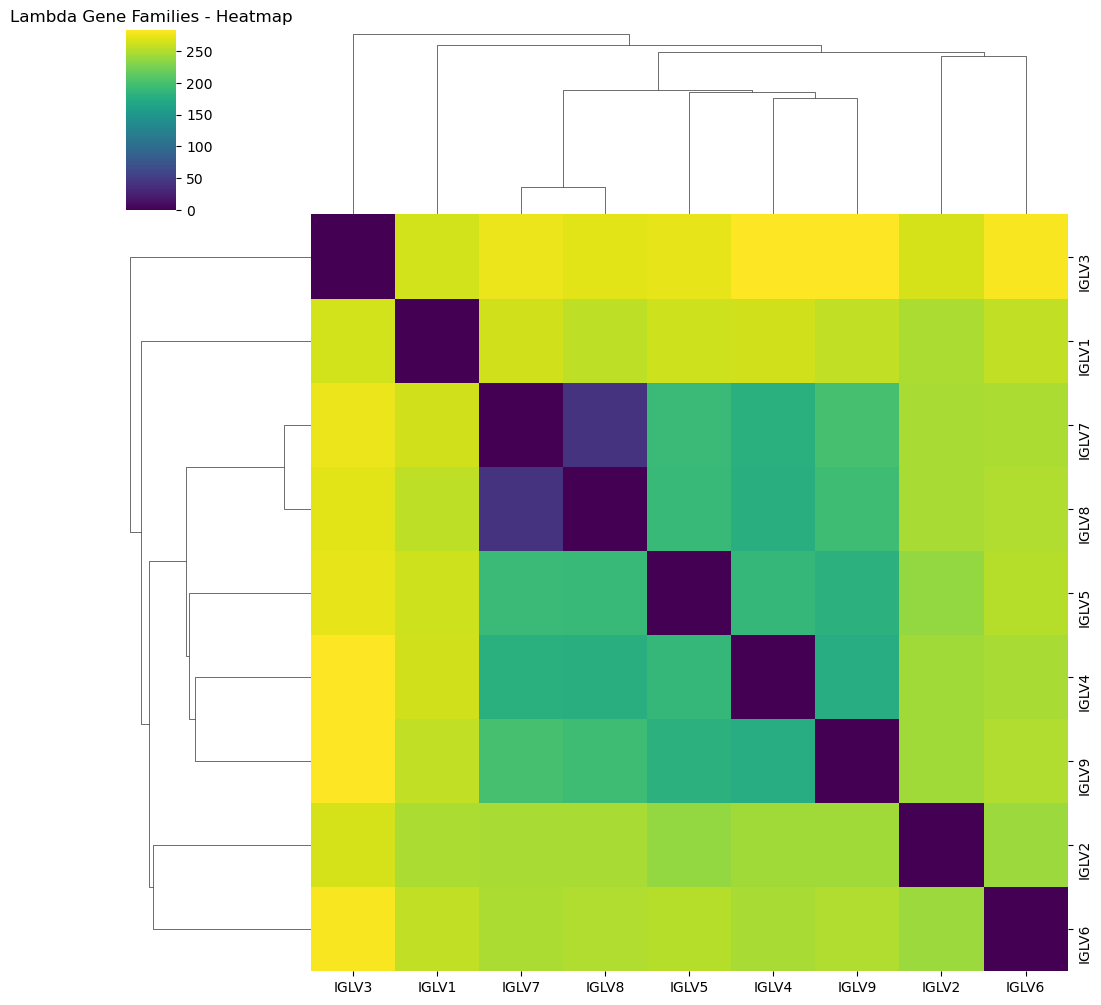

In [ ]:
#split the kappa and lambda dictionaries 
kappa_consensus = {k: v for k, v in consensus_dict.items() if 'k' in k.lower()}
lambda_consensus = {k: v for k, v in consensus_dict.items() if 'l' in k.lower()}

max_len = max(len(seq) for seq in consensus_dict.values())

def pad(seq, length):
    return seq + "_" * (length - len(seq))

kappa_consensus_padded = {k: pad(v, max_len) for k, v in kappa_consensus.items()}
lambda_consensus_padded = {k: pad(v, max_len) for k, v in lambda_consensus.items()}

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))

def cluster_and_plot(consensus_dict, title_prefix=""):
    if len(consensus_dict) < 2:
        print(f"Not enough sequences in {title_prefix} set to cluster.")
        return

    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    seq_lengths = {len(seq) for seq in sequences}
    if len(seq_lengths) > 1:
        print(f"Warning: sequences in {title_prefix} set are not the same length. Skipping.")
        return

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
    plt.title(f"{title_prefix} Gene Families - Dendrogram")
    plt.tight_layout()
    plt.show()

    sns.clustermap(dist_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix,
                   xticklabels=labels, yticklabels=labels, cmap="viridis")
    plt.title(f"{title_prefix} Gene Families - Heatmap")
    plt.show()

cluster_and_plot(kappa_consensus_padded, title_prefix="Kappa")
cluster_and_plot(lambda_consensus_padded, title_prefix="Lambda")


In [ ]:
#now to look if the clustered gene families correlate with the antigens the target 
gene_to_antigen_type = df_sars_hum.groupby('light_subclass')['antigen_species'].apply(set).to_dict()

#classifiying subclasses by antigen that they target
def classify_antigen_type(antigen_set):
    antigen_set = {s.lower().strip() for s in antigen_set}
    sars = [s for s in antigen_set if "coronavirus" in s]
    human = [s for s in antigen_set if "homo sapiens" in s]

    if sars and not human:
        return "SARS-CoV-2"
    elif human and not sars:
        return "homo sapiens"
    elif sars and human:
        return "both"

cleaned_antigen_map = {
    subclass: classify_antigen_type(antigens)
    for subclass, antigens in gene_to_antigen_type.items()
}

for subclass, label in cleaned_antigen_map.items():
    print(f"{subclass}: {label}")


IGKV1: both
IGKV10: homo sapiens
IGKV12: homo sapiens
IGKV13: homo sapiens
IGKV14: homo sapiens
IGKV16: homo sapiens
IGKV19: homo sapiens
IGKV1D: homo sapiens
IGKV2: both
IGKV2D: homo sapiens
IGKV3: both
IGKV3D: homo sapiens
IGKV4: both
IGKV5: both
IGKV6: both
IGKV8: both
IGKV9: homo sapiens
IGLV1: both
IGLV2: both
IGLV3: both
IGLV4: SARS-CoV-2
IGLV5: both
IGLV6: both
IGLV7: both
IGLV8: both
IGLV9: SARS-CoV-2
